In [35]:
# import Librairies
import pandas as pd 
import matplotlib.pyplot as plt

# Data & Clean
df = pd.read_csv(r'C:\Users\PC\Documents\Learning_PYTHON\data_jobs.csv')
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)

# Your mession this time is to learn how to merge diffrent data in one

In [36]:
# Make the Pivot Table DATA cleaned

df_usa = df [ df['job_country'] == "United States"].copy()
df_usa['job_posted_month'] = df_usa['job_posted_date'].dt.strftime('%B')

pivot_df_usa = df_usa.pivot_table (
    index='job_posted_month' ,
    columns='job_title_short' ,
    aggfunc='size'
)

# Sort the months 
pivot_df_usa.reset_index(inplace=True)
pivot_df_usa['month_no'] = pd.to_datetime(pivot_df_usa['job_posted_month'],format='%B').dt.month
pivot_df_usa.sort_values("month_no",inplace=True)
pivot_df_usa.set_index("job_posted_month",inplace=True)
pivot_df_usa.drop(columns='month_no', inplace=True)

pivot_df_usa

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114
February,447,24,6124,3060,4956,56,1258,878,1127,90
March,438,19,6218,3183,4779,59,1114,829,1150,115
April,565,40,6049,2801,4867,51,1025,781,991,112
May,279,20,4993,2976,4377,49,839,746,914,90
June,446,32,5683,2893,4645,48,1009,812,1033,93
July,581,39,5201,2570,4876,65,883,747,1095,153
August,903,39,6634,3269,6318,68,1186,903,1515,194
September,897,50,4639,3224,4568,113,805,775,1014,228


In [37]:
df_usa_sofware_pivot = pd.read_csv(r"C:\Users\PC\Documents\Learning_PYTHON\Job_DATA_2.csv")
df_usa_sofware_pivot.set_index('job_posted_month', inplace=True)

In [39]:
# We have2 data now , the 2 have the column "job_posted_month" as Index 
# Let's merge them 
df_usa_merged = pivot_df_usa.merge(df_usa_sofware_pivot , on="job_posted_month")

In [ ]:
top_5 = ( df_usa_merged
         .sum()
         .sort_values(ascending=False)
         .head()
         .index      # Get jus the values
         .tolist()   # Transforme into a list 
         )
top_5

['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'Data Analyst',
 'Data Scientist']

In [47]:
df_usa_merged = df_usa_merged[top_5]

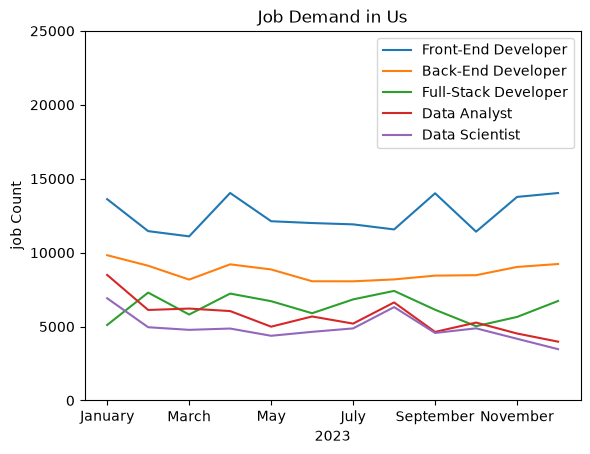

In [54]:
df_usa_merged.plot(kind = "line")
plt.title('Job Demand in Us')
plt.xlabel ('2023')
plt.ylabel("job Count")
plt.ylim(0 ,25000)   # This controle the number of Y ( as you see we wrote 25000 and the i chart its end in 25000 )
plt.legend()
plt.show()